In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
from matplotlib import pyplot as plt
from src.data_format import format_output
from src.data import DATA_OUT_PROC, DATA_FIGURE, DATA_IN_JSONS, DATA_LABELLED
from src.accuracy import *
from src.utils import *
from src.impact_def import IMPACT_SUBTYPES_MERGED
from src.utils import MODEL_NAMES_MAP


[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /Users/lseverino/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Coverage with accuracy

In [2]:
#load data extracted for a specific model


keys = ["meta-llama_llama-4-scout-17b-16e-instruct", "llama-3.1-8b-instant", "llama-3.3-70b-versatile"]
key = keys[0]
res_savename_ext = f"post_processed_labelled_reports_fixed_impact_desc3_meta-llama_llama-4-scout-17b-16e-instruct_v271025_geo_v221225"#merged_subtypes_
#f"post_processed_labelled_reports_{key}_v250925"
#f"post_processed_flags_labelled_reports_{key}_v250925"
#load data (labelled)
res_savename_lab = "post_processed_labelled_reports_impacts_all_v111025_geo_v221225"

split_lowest = False
suffix = "_geo_split_lowest" if split_lowest else "_geo"
suffix2 = suffix + "_v271025"
suffix3 = suffix + "_v171025"
#load geocoded data
extracted_df = gpd.read_file(DATA_OUT_PROC / (res_savename_ext+".gpkg"))
labelled_df = gpd.read_file(DATA_OUT_PROC / (res_savename_lab+".gpkg"))
#load corresponding matched data
filename_match = f"matched_data_ws6qt-ws5ql-geo-valuepre-strict-nans_{res_savename_ext}"
#f"matched_data_ws2-geo-valuepre-strict-nans_{res_savename_ext}"
matched_df = gpd.read_feather(DATA_OUT_PROC / (filename_match + ".feather"))

DEF_CRS_EPSG = "EPSG:4326"
drop_appeals = [
    "MDRCO023",
    "MDRGW003",
    "MDRHU005",
    "MDRPH021",
    "MDRRS015",
    "MDRMN017",
    "MDRGT009",
    "MDRPG008",
    "MDREC019",
    "MDRTN010",
    "MDRCR012",
    "MDRGE019",]
keep_appeals = [appeal for appeal in extracted_df["appealCode"].unique() if appeal not in drop_appeals]
for name in ["matched_df", "extracted_df", "labelled_df"]:
    df = locals()[name]
    if "quanti" not in df.columns:
        df["quanti"] = df["impactValue"].notnull()
        df.loc[df["quanti"],"quanti"] = "quanti"
        df.loc[df["quanti"]==False,"quanti"] = "quali"
    df = df.set_crs(DEF_CRS_EPSG, allow_override=True)
    df = df[df["appealCode"].isin(keep_appeals)]
    locals()[name] = df  # assign back

#compute metrics
matched_df["impactValue_error"] = matched_df["impactValue_error"].replace([np.inf], np.nan)
matched_df["impactValue_sim"] = matched_df.apply(lambda x: 1-max_value_diff(x["impactValue"], x["impactValue_matched"]).clip(0,1), axis=1)


In [3]:
labelled_df.impactSubtype.value_counts()

impactSubtype
Affected People                                98
Residential Buildings                          84
Agriculture and Access to Food                 50
Water, Sanitation, and Hygiene                 39
Displaced People                               35
Transportation                                 27
Infected and Ill People                        24
Unknown                                        23
Human Deaths                                   22
Economy and Livelihood                         20
Healthcare                                     16
Injured People                                 14
Education                                      11
Human Health and Wellbeing                      9
Homeless People                                 8
Power and Energy Production                     4
Informal Settlements                            3
Missing People                                  3
IT and Communication                            2
Recreation, Tourism, and Culture    

In [4]:
extracted_df.impactSubtype.value_counts()

impactSubtype
Agriculture and Access to Food                 44
Water, Sanitation, and Hygiene                 34
Residential Buildings                          32
Transportation                                 28
Unknown                                        27
Affected People                                25
Healthcare                                     23
DREF Allocation                                21
Targeted People                                20
Education                                      14
Human Health and Wellbeing                     14
Displaced People                               14
Human Deaths                                   13
Assisted People                                13
Economy and Livelihood                         10
Injured People                                  9
Homeless People                                 9
Informal Settlements                            7
Power and Energy Production                     6
Infected and Ill People             

In [5]:
## add other variables useful for analysis
#report length
extracted_df["reportSize"] = extracted_df["nathaz_text"].apply(len)

#report type
file_path = DATA_IN_JSONS / "preproc_filtered_report_types_nat_hazards_bugfix_v250925.csv"#'all_ifrc_reports_info_processed_extended_format_nb_std_units.json' "nathaz_ifrc_reports_info_processed.json"
ifrc_reports_df = pd.read_csv(file_path)

keys = labelled_df[['appealCode', 'reportDate']].drop_duplicates()
labelled_reports_raw = ifrc_reports_df.merge(keys, on=['appealCode', 'reportDate'], how='inner')


#add vars to dfs
extracted_df = extracted_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType"]], how="left", on=["appealCode", "reportDate"])
labelled_df = labelled_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType"]], how="left", on=["appealCode", "reportDate"])
matched_df = matched_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType"]], how="left", on=["appealCode", "reportDate"])


In [6]:
from src.labelling_helpers import filter_reports
ifrc_reports_df_filtered = filter_reports(ifrc_reports_df, take_latest=True)


/Users/lseverino/Documents/PhD/Projects/Como/como_project4/src/labelling_helpers.py:76: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: sort_appeal_type(x))
/Users/lseverino/Documents/PhD/Projects/Como/como_project4/src/labelling_helpers.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sort_values(date_field, ascending=False).head(1))


In [7]:
from src.sanity_checks import flag_remove_cat
remove_cats = ["Unknown","DREF Allocation", "Targeted People", "Assisted People", "Other Human Impacts", "Other Infrastructural Impacts", "Other Agricultural Impacts", "Other Service Access Impacts"]
extracted_df["flag_remove_cat"] = extracted_df.apply(flag_remove_cat, remove_cats=remove_cats, axis=1)
labelled_df["flag_remove_cat"] = labelled_df.apply(flag_remove_cat, remove_cats=remove_cats, axis=1)
matched_df["flag_remove_cat"] = matched_df.apply(flag_remove_cat, remove_cats=remove_cats, axis=1)

In [8]:
#define threshold above which we consider a match

value_error_th = 0.1
sim_th = 0.5
filter_flags = ["flag_percent", "flag_remove_cat", "flag_unit_nonstd"]#["flag_unit_nonstd"
keep_vars = ["appealType", "reportSize", "reportDate"]
extracted_df_filter = filter_by_flags(extracted_df, flag_filters=filter_flags)
labelled_df_filter = filter_by_flags(labelled_df, flag_filters=filter_flags)
matched_df_filter1 = filter_by_flags(matched_df, flag_filters=filter_flags)
matched_df_filter2 = filter_matches(matched_df_filter1, value_error_th=value_error_th, sim_th=sim_th)
coverage_df_match = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key=None)
coverage_df_match_appeal = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key="appealCode", keep_vars=keep_vars).reset_index(drop=False, names=["appealCode"])
coverage_df_match_subtype = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key="impactSubtype", group_keys=IMPACT_SUBTYPES_MERGED).reset_index(drop=False, names=["impactSubtype"])

In [9]:
from src.data_format import listify_strings


hazs = labelled_df_filter.hazards.apply(listify_strings)
hazs.explode().nunique()

9

In [10]:

nboots = 5000
df_list = []
for qq in ["quanti", "quali"]:
    labelled_dfq = labelled_df_filter[labelled_df_filter["quanti"]==qq]
    extracted_dfq = extracted_df_filter[extracted_df_filter["quanti"]==qq]
    matched_df_filterq = matched_df_filter2[matched_df_filter2["quanti"]==qq]
    n_ext = len(extracted_dfq)
    n_lab = len(labelled_dfq)
    tps = true_positives(matched_df_filterq)
    fps = false_positives(n_ext, tps)
    fns = false_negatives(n_lab, tps)
    precisions = precision_bt(tps, fps)
    recalls = recall_bt(tps, fns)
    f1s = f1_bt(tps, fps, fns)
    bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
    dict_res = {
            "quanti" : qq,
            "tps": tps,
            "f1": f1s,
            "precision": precisions,
            "recall": recalls,
            "f1_low_err": f1s - bs_metric_dict["f1_score"][0],
            "f1_high_err": bs_metric_dict["f1_score"][1] - f1s,
            "precision_low_err": precisions - bs_metric_dict["precision"][0],
            "precision_high_err": bs_metric_dict["precision"][1] - precisions,
            "recall_low_err": recalls - bs_metric_dict["recall"][0],
            "recall_high_err": bs_metric_dict["recall"][1] - recalls

    }
    df_list.append(pd.DataFrame(dict_res, index=[0]))

f1_bs_all = pd.concat(df_list)



In [11]:
group_keys = IMPACT_SUBTYPES_MERGED
group_key = "impactSubtype"
nboots = 5000
df_list = []
for group_id in group_keys:
    group_lab = labelled_df_filter[labelled_df_filter[group_key] == group_id]
    group_ext = extracted_df_filter[extracted_df_filter[group_key] == group_id]
    group_ext_match = matched_df_filter2[matched_df_filter2[group_key] == group_id]
    n_lab = len(group_lab)
    n_ext = len(group_ext)
    tps = true_positives(group_ext_match)
    fps = false_positives(n_ext, tps)
    fns = false_negatives(n_lab, tps)
    precisions = precision_bt(tps, fps)
    recalls = recall_bt(tps, fns)
    f1s = f1_bt(tps, fps, fns)
    bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
    bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
    dict_res = {
            "tps": tps,
            "f1": f1s,
            "precision": precisions,
            "recall": recalls,
            "f1_low_err": f1s - bs_metric_dict["f1_score"][0],
            "f1_high_err": bs_metric_dict["f1_score"][1] - f1s,
            "precision_low_err": precisions - bs_metric_dict["precision"][0],
            "precision_high_err": bs_metric_dict["precision"][1] - precisions,
            "recall_low_err": recalls - bs_metric_dict["recall"][0],
            "recall_high_err": bs_metric_dict["recall"][1] - recalls

    }
    df_list.append(pd.DataFrame(dict_res, index=[group_id]))
f1_bs_by_key = pd.concat(df_list).reset_index(drop=False, names=[group_key])


In [12]:
#prepare data for plots
relab_dict = {"Water, Sanitation, and Hygiene Infrastructure and Access to Water, Sanitation, and Hygiene": "Water, Sanitation and Hygiene Infrastructure\nand Access to Water, Sanitation and Hygiene",
              "Power and Energy Production Infrastructure and Access to Power and Energy": "Power and Energy Production Infrastructure\nand Access to Power and Energy",
              "IT and Communication Infrastructure and Access to IT and Communication": "IT and Communication Infrastructure\nand Access to IT and Communication"}
f1_bs_by_key.loc[f1_bs_by_key["impactSubtype"].isin(relab_dict.keys()),"impactSubtype"] = f1_bs_by_key.loc[coverage_df_match_subtype["impactSubtype"].isin(relab_dict.keys()),"impactSubtype"].map(relab_dict)
drop_types = ["DREF Allocation", "Targeted People", "Assisted People"]
f1_bs_all["quanti"].replace("quanti", "Quantitative total", inplace=True)
f1_bs_all["quanti"].replace("quali", "Qualitative total", inplace=True)
#f1_bs_all.set_index("quanti", drop=True, inplace=True)
#f1_bs_all.replace(np.nan, 0, inplace=True)
#f1_bs_by_key.replace(np.nan, 0, inplace=True)
f1_bs_by_key = f1_bs_by_key.loc[~f1_bs_by_key["impactSubtype"].isin(drop_types)]
f1_bs_by_key = f1_bs_by_key.sort_values(by="tps", ascending=False)


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_38690/1618326042.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  f1_bs_all["quanti"].replace("quanti", "Quantitative total", inplace=True)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_38690/1618326042.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which w

In [13]:
f1_bs_all

,quanti,tps,f1,precision,recall,f1_low_err,f1_high_err,precision_low_err,precision_high_err,recall_low_err,recall_high_err
0,Quantitative total,116,0.486373,0.711656,0.369427,0.059358,0.055041,0.069272,0.069801,0.053466,0.053886
0,Qualitative total,79,0.564286,0.622047,0.516340,0.069904,0.068367,0.088225,0.081953,0.077630,0.080885


In [14]:
labelled_df_filter.groupby("appealCode").quanti.value_counts().unstack().mean()

quanti
quali     10.200000
quanti    18.470588
dtype: float64

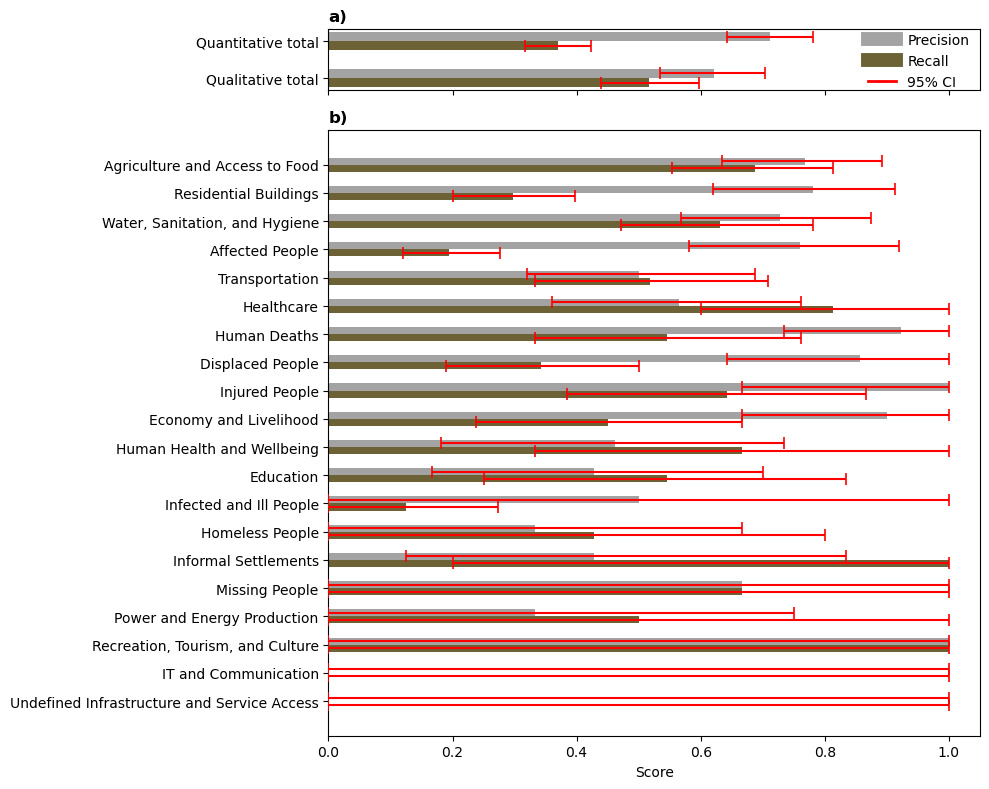

In [ ]:
import textwrap
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

metrics = ["precision", "recall"]#"f1"
colors = ["#a3a3a3", "#6c6236", "#5e0eff"]  # distinct colors for each metric

fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharey=False, sharex=True, height_ratios=[1, 10])

# --- Function to plot grouped bars with error bars ---
def plot_metrics_with_errorbars(ax, df, x_col, metrics, colors):
    n_metrics = len(metrics)
    y_positions = np.arange(len(df))
    height = 0.25  # controls bar thickness
    spacing = 0.3  # space between metric groups

    for i, metric in enumerate(metrics):
        # compute shifted y positions for each metric
        offset = (i - (n_metrics - 1)/2) * height
        y_shifted = y_positions + offset

        val = df[f"{metric}"]
        lower = df[f"{metric}_low_err"]
        upper = df[f"{metric}_high_err"]

        ax.barh(
            y_shifted,
            val,
            height=height,
            color=colors[i],
            label=metric.capitalize()
        )

        # Add horizontal error bars
        xerr = [lower, upper]
        ax.errorbar(
            val, y_shifted, xerr=xerr,
            fmt='none', ecolor='red',
            elinewidth=1.5, capsize=4, capthick=1.2, zorder=5
        )

    ax.set_yticks(y_positions)
    ax.set_yticklabels(df[x_col])
    ax.invert_yaxis()
    ax.set_xlim(0, 1.05)  # adjust if scores in [0,1]

# --- Plot bottom panel (all-level metrics) ---
plot_metrics_with_errorbars(ax[0], f1_bs_all, "quanti", metrics, colors)

# --- Plot top panel (by-key metrics) ---
plot_metrics_with_errorbars(ax[1], f1_bs_by_key, group_key, metrics, colors)

# --- Labels ---
ax[1].set_xlabel("Score")
ax[0].set_ylabel("")
ax[1].set_ylabel("")

# --- Create combined legend handles ---
err_proxy = Line2D([0], [0], color='red', lw=2, marker='_', markersize=10, label='95% CI')
bars_proxy = [Line2D([0], [0], color=c, lw=10, label=m.capitalize()) for m, c in zip(metrics, colors)]

# --- Add legend ---
#ax[1].get_legend().remove()
ax[0].legend(handles=bars_proxy + [err_proxy], loc=(0.82, -0.08), frameon=False)#title="Metrics"

ax[0].set_title("a)", fontweight="bold", loc="left")
ax[1].set_title("b)", fontweight="bold", loc="left")

plt.tight_layout()
plt.show()

fig.savefig(DATA_FIGURE / f"{'_'.join(metrics)}_vth-{value_error_th}_sth-{sim_th}_flt_{filename_match.replace(key, MODEL_NAMES_MAP[key])}.png", bbox_inches="tight", dpi=300)

In [16]:
un_matched = matched_df_filter1[(matched_df_filter1["match_sim"] <= sim_th)]
un_matched_quali = un_matched[(matched_df_filter1["quanti"] == "quali")]
un_matched_quanti = un_matched[(matched_df_filter1["quanti"] == "quanti")]


/Users/lseverino/miniforge3/envs/ifrc_llm_311/lib/python3.11/site-packages/geopandas/geodataframe.py:1896: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)
/Users/lseverino/miniforge3/envs/ifrc_llm_311/lib/python3.11/site-packages/geopandas/geodataframe.py:1896: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)


In [17]:
un_matched_quali.impactSubtype.value_counts()

impactSubtype
Healthcare                        16
Human Health and Wellbeing        12
Water, Sanitation, and Hygiene     6
Education                          5
Agriculture and Access to Food     5
Economy and Livelihood             3
Homeless People                    2
Displaced People                   1
Transportation                     1
Name: count, dtype: int64

In [18]:
un_matched.impactSubtype.value_counts()

impactSubtype
Healthcare                                     16
Human Health and Wellbeing                     12
Informal Settlements                            7
Education                                       6
Agriculture and Access to Food                  6
Water, Sanitation, and Hygiene                  6
Homeless People                                 4
Economy and Livelihood                          4
Displaced People                                1
Undefined Infrastructure and Service Access     1
Affected People                                 1
Transportation                                  1
Name: count, dtype: int64

In [19]:
print_match(un_matched[un_matched["impactSubtype"]=="Education"])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
23,MDRBJ019,Education,Economy and Livelihood,NaN,NaN,null,null,"['Couffo', 'Mono', 'Zou', 'Ouémé', 'Adoukandji...","['Mono', 'Couffo', 'Zou', 'Ouémé']",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.470855,['The localities will feel the effect of this ...,['DREF Operation Benin_Flood in Lalo Field vis...
24,MDRBJ019,Education,Human Health and Wellbeing,NaN,NaN,null,null,"['Couffo', 'Mono', 'Zou', 'Ouémé', 'Adoukandji...","['Mono', 'Couffo', 'Zou', 'Ouémé']",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.470855,['The localities will feel the effect of this ...,['DREF Operation Benin_Flood in Lalo Field vis...
25,MDRBJ019,Education,"Water, Sanitation, and Hygiene",NaN,NaN,null,null,"['Couffo', 'Mono', 'Zou', 'Ouémé', 'Adoukandji...","['Mono', 'Couffo', 'Zou', 'Ouémé']",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.470855,['The localities will feel the effect of this ...,['DREF Operation Benin_Flood in Lalo Field vis...
26,MDRBJ019,Education,Agriculture and Access to Food,NaN,NaN,null,null,"['Couffo', 'Mono', 'Zou', 'Ouémé', 'Adoukandji...","['Mono', 'Couffo', 'Zou', 'Ouémé']",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.470855,['The localities will feel the effect of this ...,['DREF Operation Benin_Flood in Lalo Field vis...
199,MDRPK026,Education,Residential Buildings,NaN,NaN,null,null,"['Balochistan', 'Khyber Pakhtunkhwa', 'Sindh',...","['Jacobabad', 'Naushero Feroz', 'Ghotki', 'Suk...",0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.707107,0.459445,"['No specific text excerpt, but typically floo...","['Areas such as Jacobabad, Naushero Feroz, Gho..."
211,MDRRW022,Education,Agriculture and Access to Food,1600.0,1000.0,children,km**2 of crop production and forestry,[],[],0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.247826,"['school kits, including exercise books, pens ...","['From 1 to 6 May, Rwanda experienced continuo..."


In [20]:
cat = "Healthcare"
ext_df = extracted_df_filter[extracted_df_filter["impactSubtype"]==cat]
lab_df = labelled_df_filter[labelled_df_filter["impactSubtype"]==cat]
m_df1 = matched_df_filter1[matched_df_filter1["impactSubtype"]==cat]
m_df2 = matched_df_filter2[matched_df_filter2["impactSubtype"]==cat]
make_coverage_accuracy_df(ext_df, lab_df, m_df2, group_key="impactSubtype", group_keys=[cat]).reset_index(drop=False, names=["impactSubtype"])

,impactSubtype,nb labelled,nb extracted,coverage,true_positives,false_negatives,false_positives,precision,recall,f1,quanti
0,Healthcare,8,8,100.0,7,1,1,0.875,0.875,0.875000,quanti
1,Healthcare,8,15,187.5,6,2,9,0.400,0.750,0.521739,quali


In [21]:
print_match(m_df2)

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
111,MDRKE058,Healthcare,Healthcare,7.0,7.0,healthcare structures,healthcare structures,[],[],1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.707107,0.878570,['The economic activities of the areas have be...,['October November December short rains season...
119,MDRKE058,Healthcare,Healthcare,59.0,59.0,healthcare structures,healthcare structures,[],[],1.0,...,1.0,1.0,1.0,0.0,0.0,1.0,0.707107,0.943787,[' 38 counties out of the 47 in the country we...,['October November December short rains season...
210,MDRRW022,Healthcare,Healthcare,8.0,8.0,healthcare structures,healthcare structures,['Rutsiro'],[],1.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.873089,"['8 health facilities (2 health Posts, 5 healt...","['From 1 to 6 May, Rwanda experienced continuo..."
212,MDRRW022,Healthcare,Healthcare,14.0,14.0,healthcare structures,healthcare structures,['Rutsiro'],['Rutsiro'],1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.000000,0.913043,['14 health centres in Rutsiro were inaccessib...,"['From 1 to 6 May, Rwanda experienced continuo..."
255,MDRSD034,Healthcare,Healthcare,80.0,80.0,healthcare structures,healthcare structures,[],[],1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.577350,0.872928,['The conflict disrupted the operations of 80%...,['The conflict disrupted the operations of 80%...
271,MDRSD034,Healthcare,Healthcare,1.0,1.0,healthcare structures,healthcare structures,['Tokar'],['Tokar'],1.0,...,1.0,1.0,1.0,0.0,1.0,1.0,0.707107,0.965526,['The city’s hospital has been severely affect...,"['- In Tokar city, Red Sea State, the situatio..."
274,MDRSD034,Healthcare,Healthcare,80.0,80.0,healthcare structures,healthcare structures,[],[],1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.577350,0.872928,['The conflict disrupted the operations of 80%...,['The conflict disrupted the operations of 80%...
330,MDRUG050,Healthcare,Healthcare,3.0,3.0,healthcare structures,healthcare structures,"['Kolir Sub County, Bukedea district']",['Kolir Sub County'],1.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.707107,0.922048,"['Kolir Sub County, Bukedea district, affectin...","['Following heavy rainfall, a rise in the wate..."
138,MDRKE058,Healthcare,Healthcare,NaN,NaN,null,null,"['Garissa', 'Tana River', 'Lamu', 'Nairobi', '...",[],1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.500000,0.631106,['The floods are exacerbating the humanitarian...,"['Destroyed infrastructure, health and educati..."
195,MDRPK026,Healthcare,Healthcare,NaN,NaN,null,null,"['Balochistan', 'Khyber Pakhtunkhwa', 'Sindh']",[],1.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.000000,0.826184,['The stagnant water in low-lying areas and th...,"['Additionally, the stagnant water in low-lyin..."


In [22]:
print_match(matched_df_filter1[(matched_df_filter1["impactSubtype_sim"] <= 0.8)]).value_counts("impactSubtype")

impactSubtype
Healthcare                                     23
Education                                      20
Human Health and Wellbeing                     20
Informal Settlements                            9
Water, Sanitation, and Hygiene                  8
Agriculture and Access to Food                  6
Homeless People                                 6
Economy and Livelihood                          3
Power and Energy Production                     3
Transportation                                  3
Residential Buildings                           2
Affected People                                 1
Displaced People                                1
Infected and Ill People                         1
Missing People                                  1
Undefined Infrastructure and Service Access     1
Name: count, dtype: int64

In [23]:
un_matched = matched_df_filter1[(matched_df_filter1["match_sim"] <= 0.5) & (matched_df_filter1["quanti"] == "quali")]
for groupid, group in un_matched.groupby("impactSubtype"):
    print(groupid)
    print(group.value_counts("impactSubtype_matched"))

Agriculture and Access to Food
impactSubtype_matched
Water, Sanitation, and Hygiene    2
Affected People                   1
Economy and Livelihood            1
Residential Buildings             1
Name: count, dtype: int64
Displaced People
impactSubtype_matched
Affected People    1
Name: count, dtype: int64
Economy and Livelihood
impactSubtype_matched
Transportation    2
Healthcare        1
Name: count, dtype: int64
Education
impactSubtype_matched
Agriculture and Access to Food    1
Economy and Livelihood            1
Human Health and Wellbeing        1
Residential Buildings             1
Water, Sanitation, and Hygiene    1
Name: count, dtype: int64
Healthcare
impactSubtype_matched
Water, Sanitation, and Hygiene    5
Agriculture and Access to Food    3
Economy and Livelihood            3
Affected People                   1
Human Health and Wellbeing        1
Power and Energy Production       1
Residential Buildings             1
Transportation                    1
Name: count, dtype: i

In [24]:
#coverage vs garbage per impactSubtype for each report
appeals = labelled_df.appealCode.unique()
value_vars = ["nb matches", "nb garbage"]#["coverage matches", "garbage"]#["nb matches", "nb garbage"]
label = "#"
yvar="impactSubtype"
#fig, axes = plt.subplots(len(appeals), 2, figsize=(15, 10), sharey=True)
#choose plotting cols
subplot_col = "match"#"quanti""match"
hue_col = "quanti"#"quanti""match"
palette_rel = ["#E61F04", "#f46c6c","#177093","#27a4d6"]
palette_rel = ["#435EF3", "#2bc26f","#435EF3", "#2bc26f", "#435EF3", "#2bc26f"]

for i, appeal in enumerate(appeals):
    ext_appeal = extracted_df_filter[extracted_df_filter["appealCode"] == appeal]
    lab_appeal = labelled_df_filter[labelled_df_filter["appealCode"] == appeal]
    matched_appeal = matched_df_filter2[matched_df_filter2["appealCode"] == appeal]
    coverage_df_match_appeal_subtype = make_coverage_accuracy_df(ext_appeal, lab_appeal, matched_appeal, group_key="impactSubtype", group_keys=IMPACT_SUBTYPES).reset_index(drop=False, names=["impactSubtype"])
    plot_df = coverage_df_match_appeal_subtype.melt(id_vars=[yvar, "quanti"], value_vars=value_vars, var_name="match", value_name="value")
    fig, axes = plot_coverage_match_v2(plot_df, subplot_col, hue_col, yvar=yvar, value_col="value", palette=palette_rel, add_avg=add_avg)
    [ax.set_xlabel(label) for ax in axes]
    fig.suptitle(appeal)

NameError: name 'IMPACT_SUBTYPES' is not defined

In [ ]:
appeal="MDRCM039"
ext_appeal = extracted_df_filter[extracted_df_filter["appealCode"] == appeal]
lab_appeal = labelled_df_filter[labelled_df_filter["appealCode"] == appeal]
matched_appeal = matched_df[matched_df["appealCode"] == appeal]
matched_appeal_flt = matched_df_filter2[matched_df_filter2["appealCode"] == appeal]
coverage_df_match_appeal_subtype = make_coverage_accuracy_df(ext_appeal, lab_appeal, matched_appeal_flt, group_key="impactSubtype", group_keys=["Targeted People"]).reset_index(drop=False, names=["impactSubtype"])

In [ ]:
coverage_df_match_appeal_subtype

,impactSubtype,nb labelled,nb extracted,coverage,nb matches,coverage matches,nb garbage,garbage,garbage/coverage,quanti
0,Targeted People,0,0,NaN,0,NaN,0,0,NaN,quanti
1,Targeted People,0,0,NaN,0,NaN,0,0,NaN,quali


In [ ]:
print_match(matched_appeal[matched_appeal["match_sim"] < 0.6])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
51,MDRCM039,Targeted People,Affected People,4800.000000,400.00,people,people,"['Extrême-Nord', 'Mayo Danay division', 'Logon...",['Ndoukoula district'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.500000,"['People Targeted: 4,800 people']","['Notably, in the Diamar division, where Ndouk..."
52,MDRCM039,Targeted People,Affected People,4800.000000,200.00,people,people,"['Extrême-Nord', 'Mayo Danay division', 'Logon...",['Mokolo district'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.500000,"['People Targeted: 4,800 people']","['Notably, in the Diamar division, where Ndouk..."
53,MDRCM039,DREF Allocation,Affected People,448994.353894,158620.00,EUR,null,"['Far North region', 'Extrême-Nord', 'Logone e...",[],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","[""Appeal MDRCM039 Country Cameroon Hazard Floo..."
54,MDRCM039,DREF Allocation,Affected People,448994.353894,400.00,EUR,people,"['Far North region', 'Extrême-Nord', 'Logone e...",['Ndoukoula district'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","['Notably, in the Diamar division, where Ndouk..."
55,MDRCM039,DREF Allocation,Affected People,448994.353894,200.00,EUR,people,"['Far North region', 'Extrême-Nord', 'Logone e...",['Mokolo district'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","['Notably, in the Diamar division, where Ndouk..."
58,MDRCM039,Agricultural Infrastructure,Crop Production and Forestry,29.980000,29.98,km**2 of crop production and forestry,km**2 of crop production and forestry,"['Logone et Chari', 'Mayo Danay']",['Far North region'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.558830,['The provisional report consolidated by the w...,['The provisional report consolidated by the w...
61,MDRCM039,Displaced People,Other Infrastructural Impacts,NaN,NaN,null,unknown,"['Yagoua', 'Blangoua', 'Mackary', 'Zina', 'Mag...","['Mayo Danay division', 'Yagoua']",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.592593,['Tens of thousands of victims are currently l...,['The peak of the floods was recorded on Augus...
62,MDRCM039,Homeless People,Other Infrastructural Impacts,NaN,NaN,null,unknown,"['Yagoua', 'Blangoua', 'Mackary', 'Zina', 'Mag...","['Mayo Danay division', 'Yagoua']",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.592593,['Tens of thousands of victims are currently l...,['The peak of the floods was recorded on Augus...
63,MDRCM039,Access to Food,Other Infrastructural Impacts,NaN,NaN,null,unknown,"['Far North region', 'Logone et Chari division...","['Mayo Danay division', 'Yagoua']",0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,0.707107,0.496823,['The lack of communication with the community...,['The peak of the floods was recorded on Augus...
64,MDRCM039,"Access to Water, Sanitation, and Hygiene",Other Infrastructural Impacts,NaN,NaN,null,unknown,"['Logone et Chari division', 'Mayo Danay divis...","['Mayo Danay division', 'Yagoua']",0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.518519,['Water sources (wells and water points) have ...,['The peak of the floods was recorded on Augus...


In [ ]:
print_match(matched_appeal)

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
49,MDRCM039,Affected People,Affected People,158620.000000,400.00,people,people,"['Logone et Chari division', 'Mayo Danay divis...",['Ndoukoula district'],1.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.826087,['The provisional report consolidated by the w...,"['Notably, in the Diamar division, where Ndouk..."
50,MDRCM039,Affected People,Affected People,158620.000000,200.00,people,people,"['Logone et Chari division', 'Mayo Danay divis...",['Mokolo district'],1.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.826087,['The provisional report consolidated by the w...,"['Notably, in the Diamar division, where Ndouk..."
51,MDRCM039,Targeted People,Affected People,4800.000000,400.00,people,people,"['Extrême-Nord', 'Mayo Danay division', 'Logon...",['Ndoukoula district'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.500000,"['People Targeted: 4,800 people']","['Notably, in the Diamar division, where Ndouk..."
52,MDRCM039,Targeted People,Affected People,4800.000000,200.00,people,people,"['Extrême-Nord', 'Mayo Danay division', 'Logon...",['Mokolo district'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.500000,"['People Targeted: 4,800 people']","['Notably, in the Diamar division, where Ndouk..."
53,MDRCM039,DREF Allocation,Affected People,448994.353894,158620.00,EUR,null,"['Far North region', 'Extrême-Nord', 'Logone e...",[],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","[""Appeal MDRCM039 Country Cameroon Hazard Floo..."
54,MDRCM039,DREF Allocation,Affected People,448994.353894,400.00,EUR,people,"['Far North region', 'Extrême-Nord', 'Logone e...",['Ndoukoula district'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","['Notably, in the Diamar division, where Ndouk..."
55,MDRCM039,DREF Allocation,Affected People,448994.353894,200.00,EUR,people,"['Far North region', 'Extrême-Nord', 'Logone e...",['Mokolo district'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","['Notably, in the Diamar division, where Ndouk..."
56,MDRCM039,Residential Buildings,Residential Buildings,8690.000000,8690.00,homes,homes,"['Logone et Chari division', 'Mayo Danay divis...",['Far North region'],1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.806380,['The provisional report consolidated by the w...,['The provisional report consolidated by the w...
57,MDRCM039,Affected Livestock and Animals,Affected Livestock and Animals,10178.000000,10178.00,affected animals,affected animals,"['Logone et Chari', 'Mayo Danay']",['Far North region'],1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.819700,['The provisional report consolidated by the w...,['The provisional report consolidated by the w...
58,MDRCM039,Agricultural Infrastructure,Crop Production and Forestry,29.980000,29.98,km**2 of crop production and forestry,km**2 of crop production and forestry,"['Logone et Chari', 'Mayo Danay']",['Far North region'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.558830,['The provisional report consolidated by the w...,['The provisional report consolidated by the w...


In [ ]:
print_match(matched_df_filter2[(matched_df_filter2["match_sim"]<0.6) & (matched_df_filter2["appealCode"]=="MDRKE058")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched


In [ ]:
print_match(matched_appeal[matched_appeal["impactSubtype"]=="Access to Power and Energy"])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched


In [ ]:
matched_appeal[matched_appeal["impactSubtype"]=="Affected People"]#[["appealCode","impactSubtype", "impactSubtype_matched", "impactValue", "impactValue_matched", "impactUnit", "impactUnit_matched", "location", "location_matched", "impactSubtype_sim", "impactUnit_sim", "geometry_sim","hazards_sim","match_sim","valueAnnotation", "annotation_matched"]]

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,country,location,...,endDay_sim,impactSubtype_sim,impactUnit_sim,geometry_sim,impactValue_sim,match_sim,impactValue_error,quanti,appealType,flag_remove_cat
49,Affected People,158620.0,NaN,NaN,exact,people,['The provisional report consolidated by the w...,0,['Cameroon'],"['Logone et Chari division', 'Mayo Danay divis...",...,1.0,1.0,1.0,1.0,0.0,0.826087,395.55,quanti,DREF Operation,False
50,Affected People,158620.0,NaN,NaN,exact,people,['The provisional report consolidated by the w...,0,['Cameroon'],"['Logone et Chari division', 'Mayo Danay divis...",...,1.0,1.0,1.0,1.0,0.0,0.826087,792.10,quanti,DREF Operation,False


In [ ]:
print_match(matched_df_filter1[(matched_df_filter1["match_sim"]<0.6) & (matched_df_filter1["appealCode"]=="MDRBD022")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
15,MDRBD022,Access to Healthcare,Other Infrastructural Impacts,NaN,NaN,null,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L...",0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.570748,['Six days of heavy rain and onrush of upstrea...,['It is also reported that embankments have be...
16,MDRBD022,Access to Healthcare,Other Infrastructural Impacts,NaN,NaN,null,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Gaddimari area', 'Lalmonirhats Hatibandha']",0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.570748,['Six days of heavy rain and onrush of upstrea...,['of union affected 776 Emergency Plan of Acti...


In [ ]:
print_match(matched_df[(matched_df["impactSubtype"]=="Informal Settlements")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
173,MDRKE058,Informal Settlements,Infected and Ill People,10.0,8.0,informal settlements,people,"['Busia County', 'Kisumu', 'Homabay', 'Migori'...",['Garsen'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,0.707107,0.280744,['49 camps have been set up within the last tw...,['October November December short rains season...
174,MDRKE058,Informal Settlements,Affected People,31015.0,31015.0,people,people,"['Nairobi County', 'Kware', 'Kibra', 'Viwandan...","['Nairobi County', 'Kware', 'Kibra', 'Viwandan...",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.739130,"['In Nairobi County, 31,015 people (6,203 hous...","['In Nairobi County, 31,015 people (6,203 hous..."
504,MDRYE011,Informal Settlements,Informal Settlements,NaN,NaN,null,null,"['Al-Khamis camp', 'Al-Hasaba', 'Aser camp', '...",['Sanaa governorate'],1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,0.707107,0.838583,['the heavy rains affected 56 families in Al-K...,"[""Situation analysis Description of the disast..."


In [ ]:
print_match(matched_df[(matched_df["impactSubtype"]=="Other Infrastructural Impacts")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
126,MDRDZ011,Other Infrastructural Impacts,"Water, Sanitation, and Hygiene Infrastructure",NaN,NaN,null,undefined WASH structures,['Béchar'],['Béchar'],0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,1.000000,0.481481,"['critical infrastructure, including 4 bridges...",['DREF Operation Algeria Flood 2024 Bechar App...
127,MDRDZ011,Other Infrastructural Impacts,Power and Energy Production Infrastructure,NaN,NaN,null,undefined power and energy production structures,['Béchar'],['Béchar'],0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,1.000000,0.481481,"['critical infrastructure, including 4 bridges...",['DREF Operation Algeria Flood 2024 Bechar App...
171,MDRKE058,Other Infrastructural Impacts,Healthcare Infrastructure,11.0,7.0,undefined structures,healthcare structures,[],[],0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.707107,0.282297,['economic activities of the areas have been s...,['October November December short rains season...
259,MDRNG041,Other Infrastructural Impacts,Other Economic Activity & Livelihood Production,NaN,NaN,null,null,"['Dantudu', 'Balakozo', 'Gidan Tudu', 'Tsitse']",[],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.555556,"['The floods ravaged farmlands and livestock, ...","['The scale of destruction is unprecedented, w..."
288,MDRPK026,Other Infrastructural Impacts,Other Infrastructural Impacts,NaN,NaN,null,null,"['Balochistan', 'Khyber Pakhtunkhwa', 'Sindh',...","['Jacobabad', 'Naushero Feroz', 'Ghotki', 'Suk...",1.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.941267,['The monsoon season causing significant infra...,"['Areas such as Jacobabad, Naushero Feroz, Gho..."
370,MDRRW022,Other Infrastructural Impacts,IT and Communication Infrastructure,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...",[],0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."
371,MDRRW022,Other Infrastructural Impacts,Power and Energy Production Infrastructure,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...",[],0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."
372,MDRRW022,Other Infrastructural Impacts,Access to Healthcare,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."
373,MDRRW022,Other Infrastructural Impacts,Mobility and Access to Transport,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."
374,MDRRW022,Other Infrastructural Impacts,Access to Education,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...",[],0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."


In [ ]:
matched_df[matched_df["match_sim"]<0.6]["impactUnit"].value_counts()

impactUnit
null                                     242
EUR                                       66
people                                    24
%                                          3
percent                                    2
km**2 of crop production and forestry      1
yuan                                       1
undefined structures                       1
informal settlements                       1
women                                      1
children under 5                           1
children                                   1
Name: count, dtype: int64

In [ ]:
extracted_df[extracted_df["appealCode"]=="MDRMZ024"][["impactUnit", "flag_percent"]]

,impactUnit,flag_percent
47,people,False
48,people,False
49,people,False
50,people,False
51,km**2 of crop production and forestry,False
52,null,False
53,EUR,False
54,EUR,False
55,people,False
56,EUR,False


In [ ]:
labelled_df[labelled_df["appealCode"]=="MDRRW022"]

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code,geometry,quanti,appealType,flag_remove_cat
474,2024-09-05,Affected People,51905.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
475,2024-09-05,Human Deaths,137.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
476,2024-09-05,Residential Buildings,5472.0,homes,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
477,2024-09-05,Water Quality and Availability,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
478,2024-09-05,Road Infrastructure,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
479,2024-09-05,"Water, Sanitation, and Hygiene Infrastructure",NaN,WASH structures,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
480,2024-09-05,Crop Production and Forestry,10.0,km**2 of crop production and forestry,approx,10.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
481,2024-09-05,Affected Livestock and Animals,NaN,affected animals,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
482,2024-09-05,Displaced People,38000.0,people,approx,38000.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
483,2024-09-05,Residential Buildings,4933.0,homes,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...",...,ADM_1,0,0,"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...","['Western Province', 'Western Province', 'West...",['RWA'],"MULTIPOLYGON (((29.0405 -2.73948, 29.0405 -2.7...",quanti,DREF Operation Final Report,False


In [ ]:
labelled_df[labelled_df["appealCode"]=="MDRRW022"]

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code,geometry,quanti,appealType,flag_remove_cat
474,2024-09-05,Affected People,51905.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
475,2024-09-05,Human Deaths,137.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
476,2024-09-05,Residential Buildings,5472.0,homes,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
477,2024-09-05,Water Quality and Availability,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
478,2024-09-05,Road Infrastructure,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
479,2024-09-05,"Water, Sanitation, and Hygiene Infrastructure",NaN,WASH structures,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
480,2024-09-05,Crop Production and Forestry,10.0,km**2 of crop production and forestry,approx,10.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
481,2024-09-05,Affected Livestock and Animals,NaN,affected animals,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
482,2024-09-05,Displaced People,38000.0,people,approx,38000.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
483,2024-09-05,Residential Buildings,4933.0,homes,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...",...,ADM_1,0,0,"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...","['Western Province', 'Western Province', 'West...",['RWA'],"MULTIPOLYGON (((29.0405 -2.73948, 29.0405 -2.7...",quanti,DREF Operation Final Report,False


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=30)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, i].set_xticklabels(axes[1, i].get_xticklabels(), rotation=30)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=30)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of t

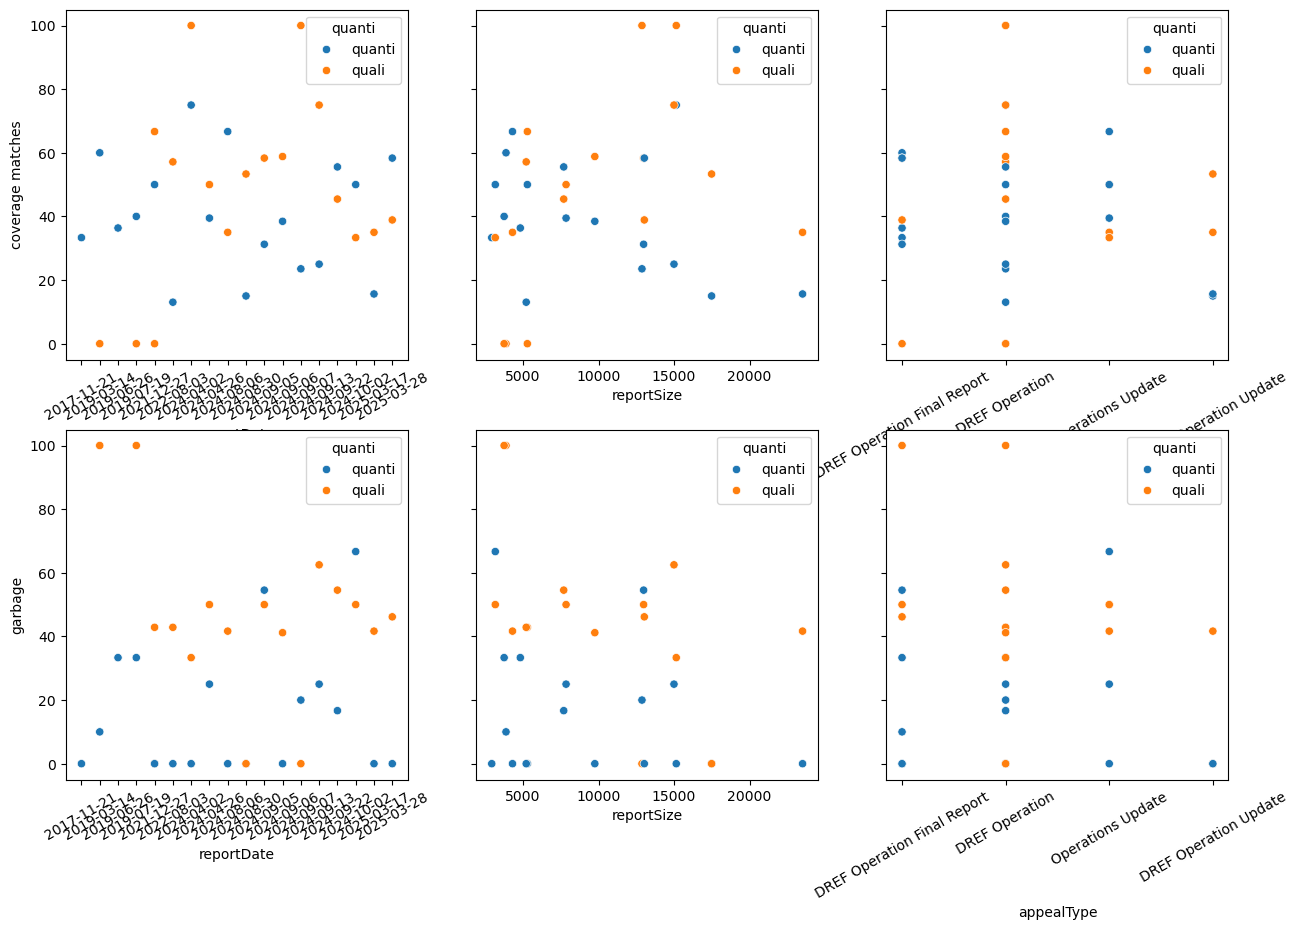

In [ ]:
#inspect sensitivity to other variables e.g. date report type, lentgth
external_vars = ["reportDate", "reportSize", "appealType"]
fig, axes = plt.subplots(2, len(external_vars), figsize=(15, 10), sharey=True, sharex=False)
coverage_df_match_appeal = coverage_df_match_appeal.sort_values("reportDate")
for i, var in enumerate(external_vars):
    sns.scatterplot(coverage_df_match_appeal, x=var, y="coverage matches", hue="quanti", ax=axes[0, i])
    sns.scatterplot(coverage_df_match_appeal, x=var, y="garbage", hue="quanti", ax=axes[1, i])
    if var in ["reportDate", "appealType"]:
        axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=30)
        axes[1, i].set_xticklabels(axes[1, i].get_xticklabels(), rotation=30)
fig.savefig(DATA_FIGURE / f"coverage_matches_by_{yvar}_external_vars_valerr_th-{value_error_th}_sim_th-{sim_th}_{filename_match}.png", bbox_inches="tight", dpi=300)

In [ ]:
#inspect sensitivity to thresholds

value_error_ths = np.arange(0.01, 0.3, 0.01)
sim_ths = np.arange(0.2, 1, 0.1)
vth_scores = []
for vth in value_error_ths:
    matched_df_filter = filter_matches(matched_df, value_error_th=vth, sim_th=0.6)
    make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key=None)
    vth_scores.append(make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key=None).set_index("quanti",drop=True)[["coverage matches", "garbage"]])

sth_scores = []
for sth in sim_ths:
    matched_df_filter = filter_matches(matched_df, value_error_th=0.1, sim_th=sth)
    sth_scores.append(make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key=None).set_index("quanti",drop=True)[["coverage matches", "garbage"]])


Overall average quanti: 176 extracted, 336 labelled, 96 correct matches, 80 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 96 correct matches, 80 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 97 correct matches, 79 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 97 correct matches, 79 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 98 correct matches, 78 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 98 correct matches, 78 garbage m

<Axes: >

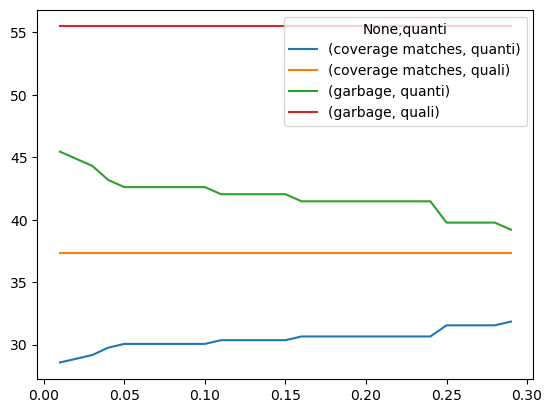

In [ ]:
sensi_vth_df = pd.concat(vth_scores, keys=value_error_ths).unstack()
sensi_vth_df.plot()

<Axes: >

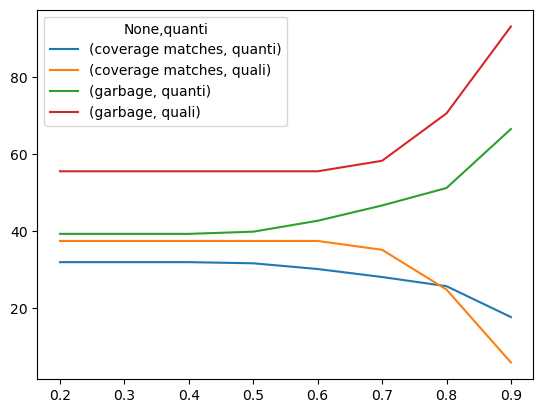

In [ ]:
sensi_sth_df = pd.concat(sth_scores, keys=sim_ths).unstack()
sensi_sth_df.plot()

In [ ]:
## Compare coverage by categories between labelled and extracted for all impacts

keys = ["meta-llama_llama-4-scout-17b-16e-instruct", "llama-3.1-8b-instant", "llama-3.3-70b-versatile"]
key = keys[0]
extracted_lab_name = f"merged_subtypes_post_processed_labelled_reports_fixed_impact_desc_{key}_v271025"
extracted_all_name = f"merged_subtypes_post_processed_all_appeals_unique_1-333_{key}_v281025"

extracted_lab = pd.read_csv(DATA_OUT_PROC / (extracted_lab_name+".csv"))
extracted_df_long = pd.read_csv(DATA_OUT_PROC / (extracted_all_name+".csv"))


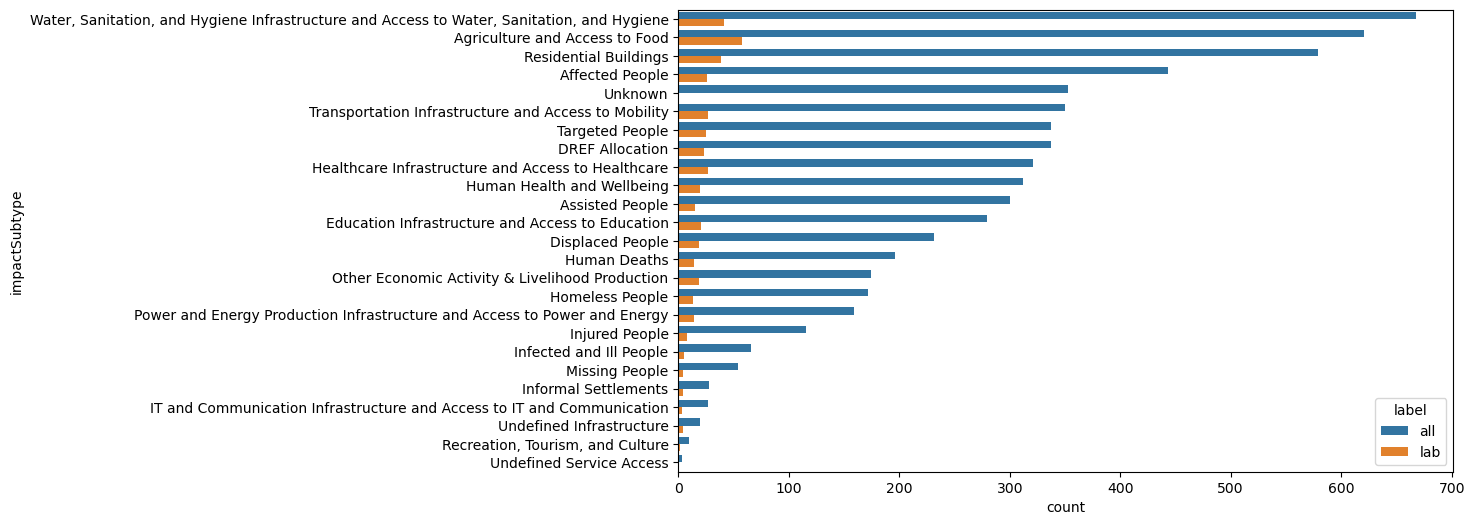

In [ ]:
#merge dfs
extracted_lab["label"] ="lab"
extracted_df_long["label"] = "all"
extracted_df_all = pd.concat([extracted_lab, extracted_df_long])
plot_df = extracted_df_all.value_counts(["impactSubtype", "label"]).reset_index()
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
sns.barplot(data=plot_df, x="count", y="impactSubtype", hue="label", axes=ax)
fig.savefig(DATA_FIGURE / f"impactSubtype_distr_lab_vs_333_{extracted_lab_name}.png", bbox_inches="tight", dpi=300)
